In [1]:
 # New Perceptron Demo: Color image segmentation

150 150


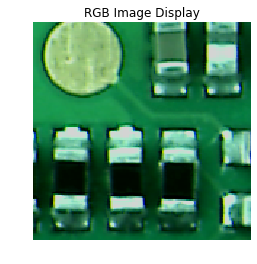

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image

# Part 1: Open the image file and display
image_name = "3503A.bmp" 
img = Image.open(image_name)

# Ensure the image is in RGB mode 
img = img.convert("RGB")

# Get image dimensions
width, height = img.size
print(width,height)

# Display the image
plt.imshow(img)
plt.title("RGB Image Display")
plt.axis('off') # Hide axes 
plt.show()

In [22]:
# original image is called"img", one pixel is shown
r, g, b = img.getpixel((10, 20))
print(r, g, b)

# Another image called "img_new" of the same dimension 150x150 is created
img_new = Image.new('RGB',(150,150),color='black')
pixels = img_new.load()

# A third image called "img_cluster" of the same dimension 150x150 is created
img_cluster = Image.new('RGB',(150,150),color='black')
pixels_cluster = img_cluster.load()

186 224 176


In [23]:
#Initial settings 

learnrate = 0.1;

W11 =  random.uniform(-0.8,0.8)
W12 =  random.uniform(-0.8,0.8)
W13 =  random.uniform(-0.8,0.8)
W21 =  random.uniform(-0.8,0.8)
W22 =  random.uniform(-0.8,0.8)
W23 =  random.uniform(-0.8,0.8)
theta1 =  random.uniform(-0.8,0.8)
theta2 =  random.uniform(-0.8,0.8)


In [24]:
# Define training instances (for the 4 colors)
tmpp = np.array([
    [5, 10, 5, 0, 0],       # black
    [0, 96, 50, 255, 0],    # green  
    [210, 210, 210, 0, 255], # white
    [0, 20, 0, 0, 0],       # black
    [194, 221, 209, 0, 255], # white
    [205, 215, 210, 0, 255], # white
    [230, 225, 235, 0, 255], # white
    [14, 106, 57, 255, 0],    # green 
    [62, 117, 78, 255, 0],    # green
    [26, 156, 81, 255, 0],    # green
    [0, 8, 0, 0, 0],          # black
    [193, 220, 112, 255, 255], # yellow
    [147, 192, 119, 255, 255], # yellow
    [0, 16, 7, 0, 0],          #black
    [177, 221, 156, 255, 255], #yellow
    [159, 204, 126, 255, 255]   #yellow
]) / 255.0

# Split `tmpp` into inputs (X1, X2, X3) and desired outputs
X1, X2, X3 = tmpp[:, 0], tmpp[:, 1], tmpp[:, 2]
desiredout1, desiredout2 = tmpp[:, 3], tmpp[:, 4]
print(X1)

[0.01960784 0.         0.82352941 0.         0.76078431 0.80392157
 0.90196078 0.05490196 0.24313725 0.10196078 0.         0.75686275
 0.57647059 0.         0.69411765 0.62352941]


In [25]:
# The code below would save the parameter values during training
# Training loop of the perceptron using the samples
num_iterations = 100
saveWeightsError = np.zeros((num_iterations, 9))

for iterations in range(num_iterations):
    totalerror = 0
    for i in range(16):  # Loop over training instances
        # Calculate the first output
        out1 = W11 * X1[i] + W12 * X2[i] + W13 * X3[i] + theta1
        out1 = 1 if out1 > 0 else 0  # Step function
        diff1 = desiredout1[i] - out1

        # Calculate the second output
        out2 = W21 * X1[i] + W22 * X2[i] + W23 * X3[i] + theta2
        out2 = 1 if out2 > 0 else 0  # Step function
        diff2 = desiredout2[i] - out2

        # Update weights and thresholds (perceptron learning rule)
        W11 += learnrate * diff1 * X1[i]
        W12 += learnrate * diff1 * X2[i]
        W13 += learnrate * diff1 * X3[i]
        theta1 += learnrate * diff1

        W21 += learnrate * diff2 * X1[i]
        W22 += learnrate * diff2 * X2[i]
        W23 += learnrate * diff2 * X3[i]
        theta2 += learnrate * diff2

        # Update total error
        totalerror += abs(diff1) + abs(diff2)

    # Save weights, thresholds, and total error for this iteration
    saveWeightsError[iterations, :] = [W11, W12, W13, theta1, W21, W22, W23, theta2, totalerror]

    # Print iteration details
    #print(f"Iteration {iterations + 1}, Total Error: {totalerror}, "
          #f"W11: {W11:.4f}, W12: {W12:.4f}, W13: {W13:.4f}, Theta1: {theta1:.4f}, "
          #f"W21: {W21:.4

In [26]:

print(saveWeightsError.shape)

(100, 9)


In [27]:
print("Trained values: ",W11,W12,W13,W21,W22,W23,theta1,theta2)
print(img.size)

# A python function is defined for finding the distance between
# the image pixel (pixel_v) and the 4 color pixels
# Return the index of the closest pixel
# 0 for black; 1 for white; 2 for green; 3 for yellow

def dist_function(pixel_v,black_v,white_v,green_v,yellow_v):
    arrp=np.array(pixel_v)
    arrb=np.array(black_v)
    arrw=np.array(white_v)
    arrg=np.array(green_v)
    arry=np.array(yellow_v)
    distb=np.sqrt(np.sum((arrp-arrb)**2))
    distw=np.sqrt(np.sum((arrp-arrw)**2))
    distg=np.sqrt(np.sum((arrp-arrg)**2))
    disty=np.sqrt(np.sum((arrp-arry)**2))
    
    my_list=[distb,distw,distg,disty]
    min_value=min(my_list)
    min_index=my_list.index(min_value)
    # print(min_value,min_index)
    
    # 0 is black, 1 is white, 2 is green, 3 is yellow
    return min_index 


Trained values:  -0.0766785936813642 0.5433827698967963 -0.3710254593436008 -0.012455432032343304 0.2315237493851397 0.5147952297936847 -0.11234697633626967 -0.3914954431333273
(150, 150)
r,g,b =  186 224 176


In [35]:
# To create a new image
black_v = [0, 0, 0]
white_v = [230, 230, 230]
green_v = [0, 100, 50]
yellow_v = [150, 190, 120]

# Iterate over each pixel in the image
width, height = img.size

for x in range(width):
    for y in range(height):
        # Extract R, G, B values (current pixel) and scaled to [0,1]
        R, G, B = img.getpixel((x, y))
        scaled_R=R/255
        scaled_G=G/255
        scaled_B=B/255

        # Calculate the first output
        out1 = W11 * scaled_R + W12 * scaled_G + W13 * scaled_B + theta1
        out1 = 1 if out1 > 0 else 0

        # Calculate the second output
        out2 = W21 * scaled_R + W22 * scaled_G + W23 * scaled_B + theta2
        out2 = 1 if out2 > 0 else 0

        # Assign colors to "img_new" based on the outputs
        if out1 == 0 and out2 == 0:
            pixels[x,y] = (0,0,0)       # Black
        elif out1 == 0 and out2 == 1:
            pixels[x,y] = (255,255,255) # White
        elif out1 == 1 and out2 == 0:
            pixels[x,y] = (0,100,50)    # Green
        elif out1 == 1 and out2 == 1:
            pixels[x,y] = (150,190,120) # Yellow

        # find closest index to the colors to "img_cluster"
        pixel_v = [R, G, B]
        closest_index = dist_function(pixel_v,black_v,white_v,green_v,yellow_v)
        if closest_index == 0:
            pixels_cluster[x,y] = (0,0,0)
        elif closest_index == 1:
            pixels_cluster[x,y] = (255,255,255)
        elif closest_index == 2:
            pixels_cluster[x,y] = (0,100,50)
        elif closest_index == 3:
            pixels_cluster[x,y] = (150,190,120)
        



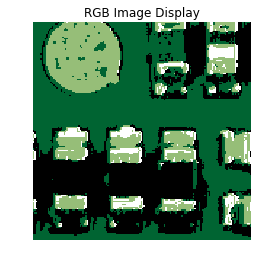

Trained values:  -0.0766785936813642 0.5433827698967963 -0.3710254593436008
Trained values:  -0.012455432032343304 0.2315237493851397 0.5147952297936847
Trained values:  -0.11234697633626967 -0.3914954431333273


In [36]:
# Display the image 1
plt.imshow(img_new)
plt.title("RGB Image Display")
plt.axis('off') # Hide axes for a cleaner image display
plt.show()

print("Trained values: ",W11,W12,W13)
print("Trained values: ",W21,W22,W23)
print("Trained values: ",theta1,theta2)

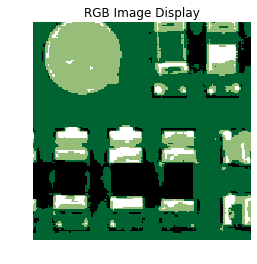

In [37]:
# Display the image 2
plt.imshow(img_cluster)
plt.title("RGB Image Display")
plt.axis('off') # Hide axes for a cleaner image display
plt.show()

In [38]:
# The code below would display the parameter values during training

100


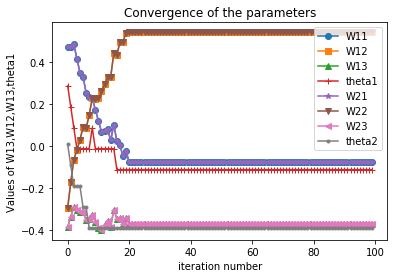

In [39]:
save_W11 = saveWeightsError[:,0]
save_W12 = saveWeightsError[:,1]
save_W13 = saveWeightsError[:,2]
save_theta1 = saveWeightsError[:,3]
save_W21 = saveWeightsError[:,4]
save_W22 = saveWeightsError[:,5]
save_W23 = saveWeightsError[:,6]
save_theta2 = saveWeightsError[:,7]

print(len(save_W11))

xaxis = list(range(len(save_W11)))

plt.plot(xaxis,save_W11,label = 'W11', marker = 'o')
plt.plot(xaxis,save_W12,label = 'W12', marker = 's')
plt.plot(xaxis,save_W13,label = 'W13', marker = '^')
plt.plot(xaxis,save_theta1,label = 'theta1', marker = '+')
plt.plot(xaxis,save_W11,label = 'W21', marker = '*')
plt.plot(xaxis,save_W12,label = 'W22', marker = 'v')
plt.plot(xaxis,save_W13,label = 'W23', marker = '<')
plt.plot(xaxis,save_theta2,label = 'theta2', marker = '.')

#Add titles and labels
plt.title('Convergence of the parameters')
plt.xlabel('iteration number')
plt.ylabel('Values of W13,W12,W13,theta1')

plt.legend() # To show the legend for the curves
#plt.grid()   # To show the grid
#plt.ylim(-4, 8) 
plt.show()   # To display the plot

100


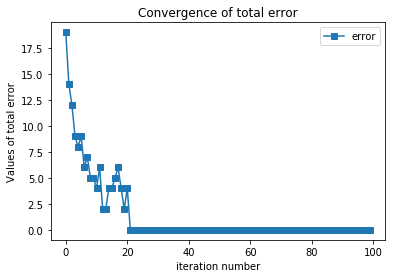

In [40]:
save_error = saveWeightsError[:,8]
print(len(save_error))

xaxis = list(range(len(save_error)))
plt.plot(xaxis,save_error,label = 'error', marker = 's')
#Add titles and labels
plt.title('Convergence of total error')
plt.xlabel('iteration number')
plt.ylabel('Values of total error')

plt.legend() # To show the legend for the curves
#plt.grid()   # To show the grid
#plt.ylim(-4, 8) 
plt.show()   # To display the plot

In [20]:
# End of Demo

In [42]:
# Another attempt to implement the perceptron, using sign function
# The code below would save the parameter values during training
# Training loop using the samples

# new image called "img_sign" is created
img_sign = Image.new('RGB',(150,150),color='black')
pixels_sign = img_sign.load()

learnrate = 0.01;

#------------------------------------------------
# An attempt to start with random values
W11 =  random.uniform(-0.8,0.8)
W12 =  random.uniform(-0.8,0.8)
W13 =  random.uniform(-0.8,0.8)
W21 =  random.uniform(-0.8,0.8)
W22 =  random.uniform(-0.8,0.8)
W23 =  random.uniform(-0.8,0.8)
theta1 =  random.uniform(-0.8,0.8)
theta2 =  random.uniform(-0.8,0.8)
#------------------------------------------------

# Define training instances (for the 4 colors) [ changes]
tmpp = np.array([
    [5, 10, 5, -255, -255],       # black
    [0, 96, 50, 255, -255],    # green  
    [210, 210, 210, -255, 255], # white
    [0, 20, 0, -255, -255],       # black
    [194, 221, 209, -255, 255], # white
    [205, 215, 210, -255, 255], # white
    [230, 225, 235, -255, 255], # white
    [14, 106, 57, 255, -255],    # green 
    [62, 117, 78, 255, -255],    # green
    [26, 156, 81, 255, -255],    # green
    [0, 8, 0, -255, -255],          # black
    [193, 220, 112, 255, 255], # yellow
    [147, 192, 119, 255, 255], # yellow
    [0, 16, 7, -255, -255],          #black
    [177, 221, 156, 255, 255], #yellow
    [159, 204, 126, 255, 255]   #yellow
]) / 255.0

# Split `tmpp` into inputs (X1, X2, X3) and desired outputs
X1, X2, X3 = tmpp[:, 0], tmpp[:, 1], tmpp[:, 2]
desiredout1, desiredout2 = tmpp[:, 3], tmpp[:, 4]

#------------------------------------------------

num_iterations = 300
saveWeightsError = np.zeros((num_iterations, 9))
totalerror = 0

for iterations in range(num_iterations):
    totalerror = 0
    for i in range(16):  # Loop over training instances
        # Calculate the first output
        out1 = W11 * X1[i] + W12 * X2[i] + W13 * X3[i] + theta1
        out1 = 1 if out1 > 0 else -1  # Sign function [ changes]
        diff1 = desiredout1[i] - out1

        # Calculate the second output
        out2 = W21 * X1[i] + W22 * X2[i] + W23 * X3[i] + theta2
        out2 = 1 if out2 > 0 else -1  # Sign function [ changes]
        diff2 = desiredout2[i] - out2

        # Update weights and thresholds (perceptron learning rule)
        W11 += learnrate * diff1 * X1[i]
        W12 += learnrate * diff1 * X2[i]
        W13 += learnrate * diff1 * X3[i]
        theta1 += learnrate * diff1

        W21 += learnrate * diff2 * X1[i]
        W22 += learnrate * diff2 * X2[i]
        W23 += learnrate * diff2 * X3[i]
        theta2 += learnrate * diff2

        # Update total error
        if (abs(diff1) + abs(diff2)) > 0:
            totalerror += 1

    # Save weights, thresholds, and total error for this iteration
    saveWeightsError[iterations, :] = [W11, W12, W13, theta1, W21, W22, W23, theta2, totalerror]


In [43]:
# To create a new image with pixels_sign
black_v = [0, 0, 0]
white_v = [230, 230, 230]
green_v = [0, 100, 50]
yellow_v = [150, 190, 120]

# Iterate over each pixel in the image
width, height = img.size

for x in range(height):
    for y in range(width):
        # Extract R, G, B values of current pixel, scaled to [0,1]
        R, G, B = img.getpixel((x, y))
        scaled_R = R/255
        scaled_G = G/255
        scaled_B = B/255

        # Calculate the first output
        out1 = W11 * scaled_R + W12 * scaled_G + W13 * scaled_B + theta1
        out1 = 1 if out1 > 0 else -1  #[ changes]

        # Calculate the second output
        out2 = W21 * scaled_R + W22 * scaled_G + W23 * scaled_B + theta2
        out2 = 1 if out2 > 0 else -1  #[ changes]

        # Assign colors based on the outputs
        if out1 == -1 and out2 == -1:        #[ changes]
            pixels_sign[x,y] = (0,0,0)       # Black
        elif out1 == -1 and out2 == 1:       #[ changes]
            pixels_sign[x,y] = (255,255,255) # White
        elif out1 == 1 and out2 == -1:       #[ changes]
            pixels_sign[x,y] = (0,100,50)    # Green
        elif out1 == 1 and out2 == 1:        #[ changes]
            pixels_sign[x,y] = (150,190,120) # Yellow

        # find closest index to the colors
        pixel_v = [R, G, B]
        closest_index = dist_function(pixel_v,black_v,white_v,green_v,yellow_v)
        if closest_index == 0:
            pixels_cluster[x,y] = (0,0,0)
        elif closest_index == 1:
            pixels_cluster[x,y] = (255,255,255)
        elif closest_index == 2:
            pixels_cluster[x,y] = (0,100,50)
        elif closest_index == 3:
            pixels_cluster[x,y] = (150,190,120)
        



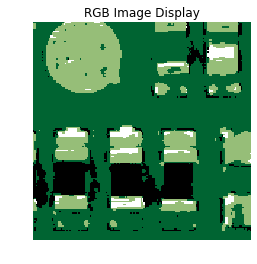

Trained values:  -0.21299101160483452 0.23423122311661163 -0.007846681119884737
Trained values:  -0.10837944627797355 0.19377078924762242 0.3595752883945428
Trained values:  -0.03656280536266557 -0.22969268326438358


In [44]:
# Display the image img_sign
plt.imshow(img_sign)
plt.title("RGB Image Display")
plt.axis('off') # Hide axes for a cleaner image display
plt.show()

print("Trained values: ",W11,W12,W13)
print("Trained values: ",W21,W22,W23)
print("Trained values: ",theta1,theta2)

300


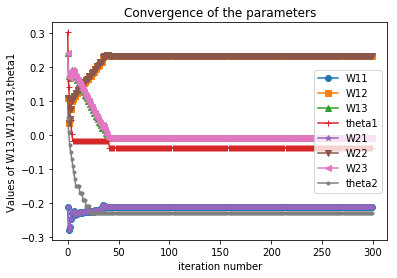

In [45]:
# To display the parameters
save_W11 = saveWeightsError[:,0]
save_W12 = saveWeightsError[:,1]
save_W13 = saveWeightsError[:,2]
save_theta1 = saveWeightsError[:,3]
save_W21 = saveWeightsError[:,4]
save_W22 = saveWeightsError[:,5]
save_W23 = saveWeightsError[:,6]
save_theta2 = saveWeightsError[:,7]

print(len(save_W11))

xaxis = list(range(len(save_W11)))

plt.plot(xaxis,save_W11,label = 'W11', marker = 'o')
plt.plot(xaxis,save_W12,label = 'W12', marker = 's')
plt.plot(xaxis,save_W13,label = 'W13', marker = '^')
plt.plot(xaxis,save_theta1,label = 'theta1', marker = '+')
plt.plot(xaxis,save_W11,label = 'W21', marker = '*')
plt.plot(xaxis,save_W12,label = 'W22', marker = 'v')
plt.plot(xaxis,save_W13,label = 'W23', marker = '<')
plt.plot(xaxis,save_theta2,label = 'theta2', marker = '.')

#Add titles and labels
plt.title('Convergence of the parameters')
plt.xlabel('iteration number')
plt.ylabel('Values of W13,W12,W13,theta1')

plt.legend() # To show the legend for the curves
#plt.grid()   # To show the grid
#plt.ylim(-4, 8) 
plt.show()   # To display the plot

300


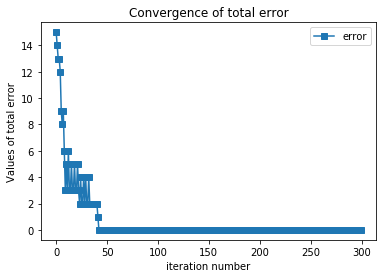

In [46]:
# To display the totalerror
save_error = saveWeightsError[:,8]
print(len(save_error))

xaxis = list(range(len(save_error)))
plt.plot(xaxis,save_error,label = 'error', marker = 's')
#Add titles and labels
plt.title('Convergence of total error')
plt.xlabel('iteration number')
plt.ylabel('Values of total error')

plt.legend() # To show the legend for the curves
#plt.grid()   # To show the grid
#plt.ylim(-4, 8) 
plt.show()   # To display the plot

In [596]:
# sample code
my_list=[50,20,80,10,70]
min_value=min(my_list)
min_index=my_list.index(min_value)
print(min_value,min_index)

list1=[1,2,3]
list2=[5,6,7]
arr1=np.array(list1)
arr2=np.array(list2)
sum_square_diff = np.sqrt(np.sum((arr1-arr2)**2))
print('distance = ',sum_square_diff)

def dist_function(pixel_v,black_v,white_v,green_v,yellow_v):
    arrp=np.array(pixel_v)
    arrb=np.array(black_v)
    arrw=np.array(white_v)
    arrg=np.array(green_v)
    arry=np.array(yellow_v)
    distb=np.sqrt(np.sum((arrp-arrb)**2))
    distw=np.sqrt(np.sum((arrp-arrw)**2))
    distg=np.sqrt(np.sum((arrp-arrg)**2))
    disty=np.sqrt(np.sum((arrp-arry)**2))
    
    my_list=[distb,distw,distg,disty]
    min_value=min(my_list)
    min_index=my_list.index(min_value)
    # print(min_value,min_index)
    
    # 0 is black, 1 is white, 2 is green, 3 is yellow
    return min_index 

pixel_v = [0, 30, 10]
black_v = [20, 10, 30]
white_v = [255, 255, 255]
green_v = [0, 100, 50]
yellow_v = [150, 190, 120]
closest_index = dist_function(pixel_v,black_v,white_v,green_v,yellow_v)
print(closest_index)
    

10 3
distance =  6.928203230275509
34.64101615137755 0
0
